### SARIMA on Stock Price Data

#### 1) Importing Necessary Libraries:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmdarima import auto_arima

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error

#### 2) Loading Data:

In [3]:
df = pd.read_csv('stock_price.csv', index_col= 0, parse_dates= True)

In [4]:
df.head()

,y
ds,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


In [5]:
df.shape

(204, 1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 204 entries, 1991-07-01 to 2008-06-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       204 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


In [7]:
df.describe()

,y
count,204.000000
mean,10.694430
std,5.956998
min,2.814520
25%,5.844095
50%,9.319345
75%,14.289964
max,29.665356


##### Adding Index Frequency:

In [8]:
df.index

DatetimeIndex(['1991-07-01', '1991-08-01', '1991-09-01', '1991-10-01',
               '1991-11-01', '1991-12-01', '1992-01-01', '1992-02-01',
               '1992-03-01', '1992-04-01',
               ...
               '2007-09-01', '2007-10-01', '2007-11-01', '2007-12-01',
               '2008-01-01', '2008-02-01', '2008-03-01', '2008-04-01',
               '2008-05-01', '2008-06-01'],
              dtype='datetime64[ns]', name='ds', length=204, freq=None)

In [9]:
df.index.freq = 'MS'

In [10]:
df.index

DatetimeIndex(['1991-07-01', '1991-08-01', '1991-09-01', '1991-10-01',
               '1991-11-01', '1991-12-01', '1992-01-01', '1992-02-01',
               '1992-03-01', '1992-04-01',
               ...
               '2007-09-01', '2007-10-01', '2007-11-01', '2007-12-01',
               '2008-01-01', '2008-02-01', '2008-03-01', '2008-04-01',
               '2008-05-01', '2008-06-01'],
              dtype='datetime64[ns]', name='ds', length=204, freq='MS')

##### Visualizing Data:

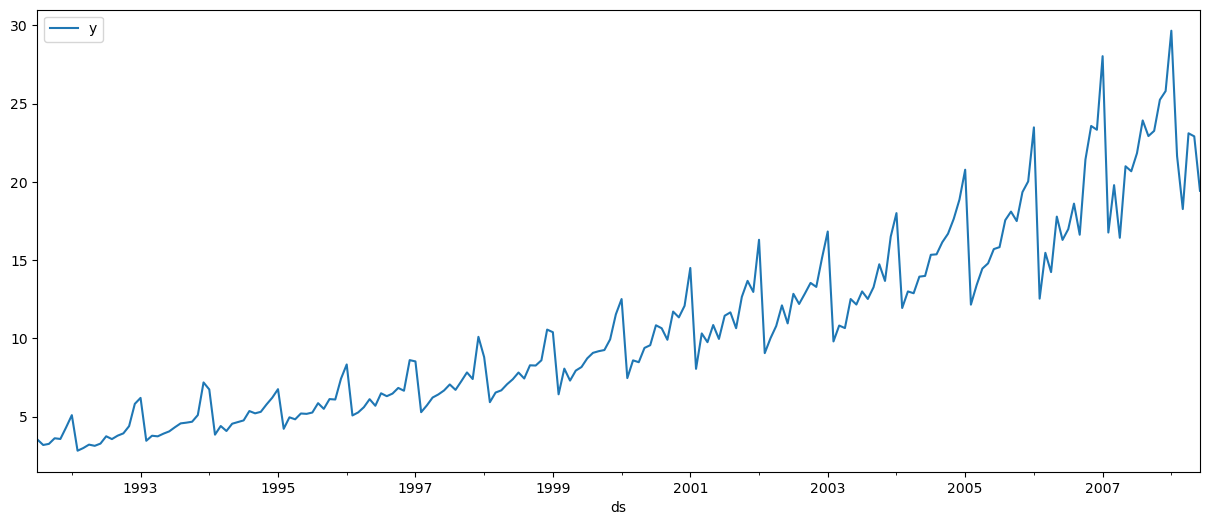

In [11]:
df.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 3) ETS Decomposition:

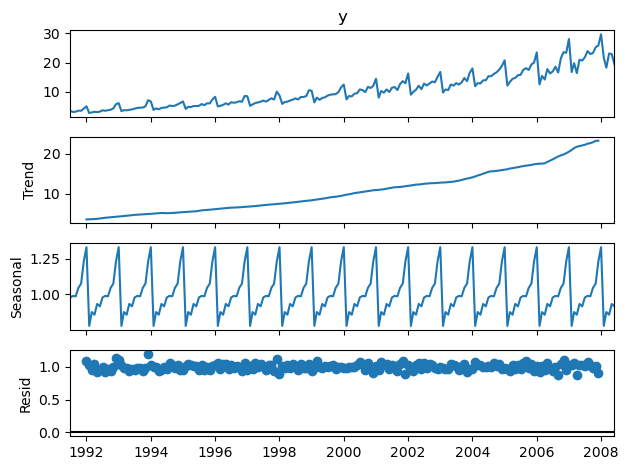

In [12]:
decomp = seasonal_decompose(df['y'], model= 'multiplicative')
decomp.plot();

#### 4) USing AUTO ARIMA to Decide Orders for SARIMA Model:

In [14]:
grid = auto_arima(y= df['y'],
                 seasonal= True,
                 m= 12,
                 trace= True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=526.837, Time=0.97 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=659.245, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=560.558, Time=0.09 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=529.539, Time=0.23 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=525.356, Time=0.80 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=551.838, Time=0.15 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=526.365, Time=1.90 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=530.219, Time=0.56 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=inf, Time=3.54 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=527.568, Time=0.61 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=529.582, Time=0.51 sec
 ARIMA(3,1,2)(0,1,1)[12]             : AIC=520.313, Time=0.72 sec
 ARIMA(3,1,2)(0,1,0)[12]             : AIC=544.911, Time=0.19 sec
 ARIMA(3,1,2)(1,1,1)[12]             : AIC=521.966, Time=1.00 sec
 ARIMA(3,1,2)(0,1,2)[12]             

In [15]:
grid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  204
Model:             SARIMAX(4, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -252.988
Date:                            Mon, 22 Dec 2025   AIC                            519.977
Time:                                    18:47:46   BIC                            542.743
Sample:                                07-01-1991   HQIC                           529.198
                                     - 06-01-2008                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2112      0.126     -1.683      0.092      -0.457       0.035
ar.L2          0.1221      0.120      1.018      0.309      -0.113       0.357
ar.L3          0.1174      0.090      1.311      0.190      -0.058       0.293
ar.L4         -0.2340      0.077     -3.021      0.003      -0.386      -0.082
ma.L1         -0.7149      0.113     -6.315      0.000      -0.937      -0.493
ma.S.L12      -0.4786      0.063     -7.613      0.000      -0.602      -0.355
sigma2         0.8086      0.053     15.389      0.000       0.706       0.912
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               176.73
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):              15.18   Skew:                            -0.36
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

`(p, d, q)(P, D, Q)[m] = (4,1,1)(0,1,1)[12]`

#### 5) Train Test Split:

In [16]:
len(df)

204

In [17]:
train_data = df[:180]
test_data = df[180:]
print(train_data.shape, test_data.shape)

(180, 1) (24, 1)


#### 5) SARIMA(4,1,1)(0,1,1)[12] Model:

In [20]:
sarima = SARIMAX(endog= train_data['y'],
                order= (4, 1, 1),
                seasonal_order= (0, 1, 1, 12))

result = sarima.fit()

In [21]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  180
Model:             SARIMAX(4, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -155.478
Date:                            Mon, 22 Dec 2025   AIC                            324.956
Time:                                    18:53:24   BIC                            346.782
Sample:                                07-01-1991   HQIC                           333.815
                                     - 06-01-2006                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0223      0.090     -0.249      0.804      -0.199       0.154
ar.L2          0.3070      0.090      3.397      0.001       0.130       0.484
ar.L3          0.1187      0.082      1.447      0.148      -0.042       0.279
ar.L4          0.0229      0.087      0.263      0.793      -0.148       0.194
ma.L1         -0.9355      0.048    -19.514      0.000      -1.030      -0.842
ma.S.L12      -0.2246      0.072     -3.127      0.002      -0.365      -0.084
sigma2         0.3718      0.038      9.902      0.000       0.298       0.445
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 8.27
Prob(Q):                              0.82   Prob(JB):                         0.02
Heteroskedasticity (H):               4.72   Skew:                            -0.31
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##### Predictions on Test Data:

In [22]:
start = len(train_data)
end = len(train_data) + len(test_data) -1

preds = result.predict(start= start, end= end)

In [23]:
preds.head()

2006-07-01    17.734353
2006-08-01    18.672056
2006-09-01    19.406638
2006-10-01    19.056427
2006-11-01    20.639150
Freq: MS, Name: predicted_mean, dtype: float64

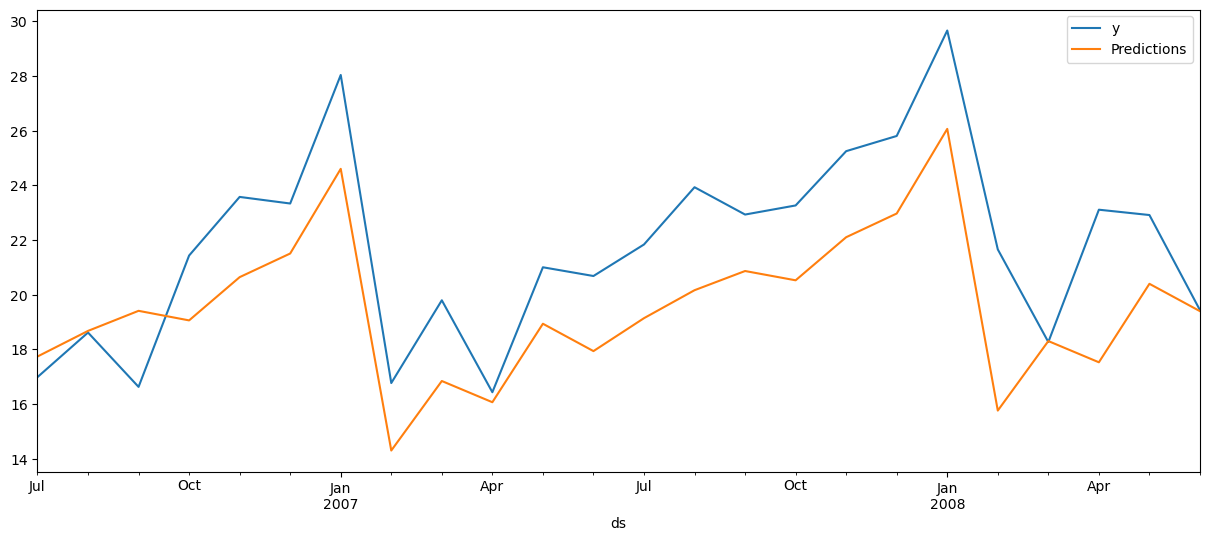

In [24]:
# Plotting Test Data and Predictions:

test_data["y"].plot(figsize= (15,6), legend= True)
preds.plot(label= "Predictions", legend= True)
plt.show()

##### Model Evaluation:

In [25]:
np.sqrt(mean_squared_error(test_data['y'], preds))

np.float64(2.8939950063822963)

##### Training on Full Data and Forecasting:

In [26]:
final_sarima = SARIMAX(endog= df['y'],
                      order= (4, 1, 1),
                      seasonal_order= (0, 1, 1, 12))

final_result = final_sarima.fit()

In [27]:
final_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  204
Model:             SARIMAX(4, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -252.988
Date:                            Mon, 22 Dec 2025   AIC                            519.977
Time:                                    18:57:10   BIC                            542.743
Sample:                                07-01-1991   HQIC                           529.198
                                     - 06-01-2008                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2112      0.126     -1.683      0.092      -0.457       0.035
ar.L2          0.1221      0.120      1.018      0.309      -0.113       0.357
ar.L3          0.1174      0.090      1.311      0.190      -0.058       0.293
ar.L4         -0.2340      0.077     -3.021      0.003      -0.386      -0.082
ma.L1         -0.7149      0.113     -6.315      0.000      -0.937      -0.493
ma.S.L12      -0.4786      0.063     -7.613      0.000      -0.602      -0.355
sigma2         0.8086      0.053     15.389      0.000       0.706       0.912
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               176.73
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):              15.18   Skew:                            -0.36
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
# Forecasting:

forecast = final_result.predict(start= len(df),
                               end= len(df) + 11)

forecast.head()

2008-07-01    25.178306
2008-08-01    23.462204
2008-09-01    24.380656
2008-10-01    26.256820
2008-11-01    26.669766
Freq: MS, Name: predicted_mean, dtype: float64

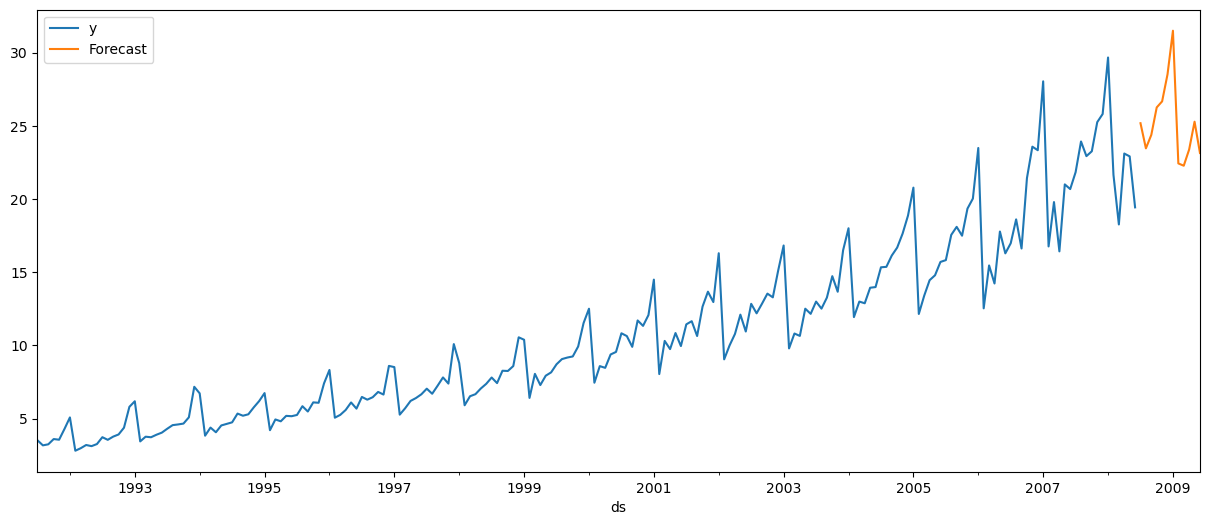

In [30]:
# Plotting Historic and Forecast Data:

df["y"].plot(figsize= (15,6), legend= True)
forecast.plot(label= "Forecast", legend= True)
plt.show()